# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [42]:
# импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from math import * 
from statsmodels.stats.proportion import proportions_ztest

In [43]:
# сохраняем датафрейм
sessions_history = pd.read_csv('sessions_project_history.csv')

# выводим первые 5 строк датафрейма
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [44]:
# считаем количество сессий для каждого пользователя 
sessions = sessions_history.groupby('user_id')['session_id'].count().reset_index(name = 'session_count')
sessions

,user_id,session_count
0,00005FB6A13A6FBE,2
1,0000B15A18D77ED9,3
2,0000C4E3A4A571A9,2
3,000293FAF9E67A81,4
4,00029C5AE889A6C3,2
...,...,...
134034,FFFCDE7746148710,4
134035,FFFDD413285E753F,3
134036,FFFECBA0F2578AB0,2
134037,FFFEDB68228B5F21,5


In [45]:
# находим id пользователя с максимальным кол-вом сессий
max_id = sessions[sessions['session_count'] == sessions['session_count'].max()]['user_id'].head(1)
max_id = max_id.iloc[0]

# выводим информацию о пользователе с максимальным кол-вом сессий
sessions_history[sessions_history['user_id'] == max_id] 

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

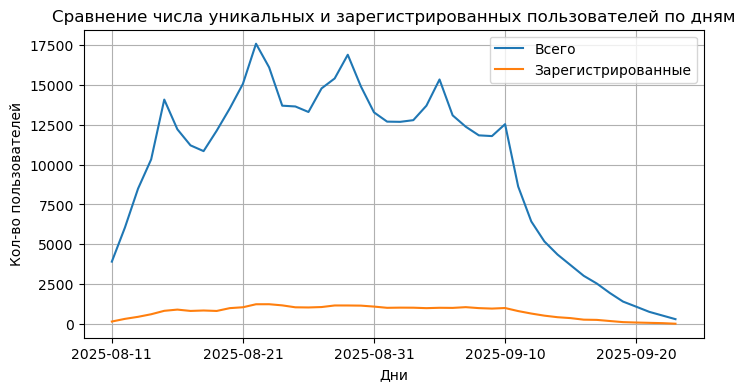

In [46]:
# считаем кол-во уникальных и зарегистрированных пользователей по дням
dynamics = sessions_history.groupby('session_date').agg({'registration_flag':['count', 'sum']})

# строим график
dynamics.plot(figsize = (8, 4))
plt.grid()
plt.legend(['Всего', 'Зарегистрированные'])
plt.xlabel('Дни')
plt.ylabel('Кол-во пользователей')
plt.title('Сравнение числа уникальных и зарегистрированных пользователей по дням')
plt.show()

Число уникальных пользователей колеблется в диапозоне примерно от 500 до 17500. Метрика нестабильна, постоянно происходит рост и спады, с середины сентября наблюдается самый резкий спад. Число зарегистрированных пользователей более стабильно, всегда меньше 2500. С середины сентября количество зарегистрированных пользователей также пошло на спад. 

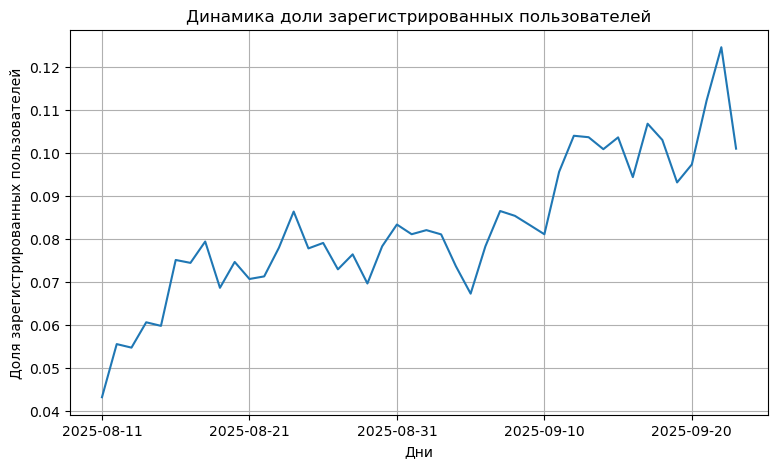

In [47]:
# считаем долю зарегистрированных пользователей по дням
dynamics['percent'] = dynamics['registration_flag', 'sum']/dynamics['registration_flag','count']

# строим график
dynamics['percent'].plot(figsize = (9, 5))
plt.grid()
plt.xlabel('Дни')
plt.ylabel('Доля зарегистрированных пользователей')
plt.title('Динамика доли зарегистрированных пользователей')
plt.show()

Доля зарегистрированных пользователей выросла с середины августа по конец сентября, однако скорее всего это связано не с увеличенным количеством новых регистраций, а с резким падением числа уникальных пользователей.

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

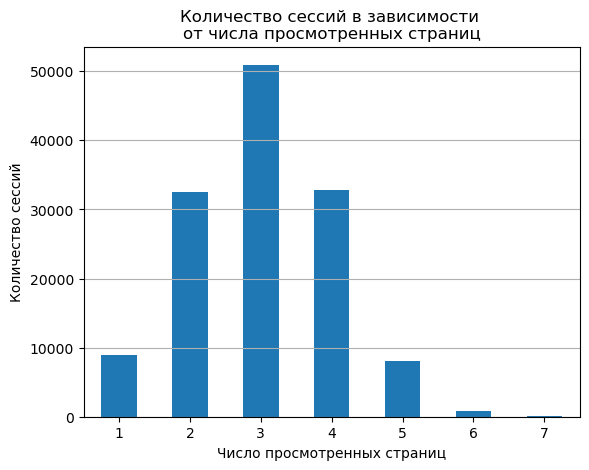

In [48]:
# оставим только строки с первыми сессиями
pages =  sessions_history[sessions_history['session_number'] == 1]

# посчитаем кол-во первых сессий для каждого значения просмотренных страниц
grouped = pages.groupby('page_counter')['session_id'].count()

# построим график
grouped.plot(kind = 'bar', rot = 0)
plt.title('Количество сессий в зависимости \nот числа просмотренных страниц')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество сессий')
plt.grid(axis = 'y')
plt.show()

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

In [49]:
# создаем новый столбец (1 - если кол-во просмотренных страниц больше 3, иначе 0)
sessions_history['good_session'] = 1
sessions_history.loc[sessions_history['page_counter'] < 4, 'good_session'] = 0

# проверим, что получилось
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,good_session
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone,0
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android,1
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC,1
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android,1
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android,0


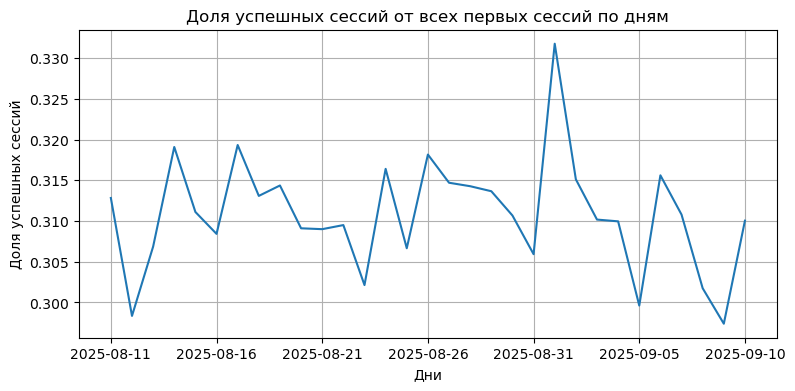

In [50]:
# оставляем только строки с 1 сессиями
good_percent = sessions_history[sessions_history['session_number'] == 1]

# считаем долю успешных сессий от всех
grouped = good_percent.groupby('session_date')['good_session'].mean()

# строим график
plt.figure(figsize = (9, 4))
grouped.plot()
plt.title('Доля успешных сессий от всех первых сессий по дням')
plt.xlabel('Дни')
plt.ylabel('Доля успешных сессий')
plt.grid()
plt.show()

Доля успешных первых сессий находится в диапозоне примерно от 0,28 до 0,33. В этом диапозоне она постоянно то снижается, то растет, но, в целом, можно сказать что метрика стабильна, т.к. разброс значений небольшой.

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [51]:
# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p1 = 0.3 # Базовый уровень доли
mde = p1 * 0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p1, p1 + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [52]:
# считаем кол-во уникальных пользователей по дням
new_df = sessions_history.groupby('session_date')['user_id'].nunique()

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = new_df.mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(int(sample_size) * 2 / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с данными за первый день проведения A/B-теста, то есть за 2025-10-14 `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [53]:
# сохраняем датафрейм 
sessions_test_part = pd.read_csv('sessions_project_test_part.csv')

In [54]:
# кол-во уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения
grouped = sessions_test_part.groupby('test_group')['user_id'].nunique()
print(grouped)

# сохраняем размер каждой группы
n_a = grouped['A']
n_b = grouped['B']

test_group
A    1477
B    1466
Name: user_id, dtype: int64


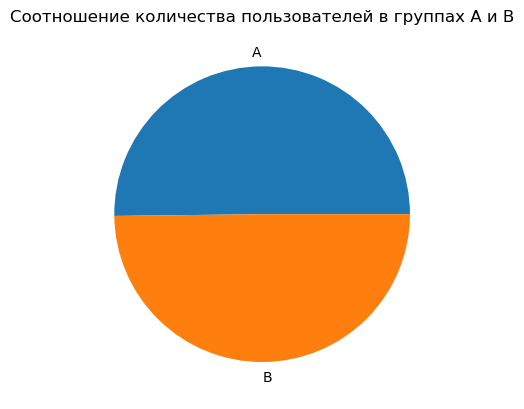

In [55]:
# строим график
grouped.plot(kind = 'pie')
plt.grid()
plt.title('Соотношение количества пользователей в группах A и В')
plt.ylabel('')
plt.show()

In [56]:
# Рассчитаем процентную разницу в количестве пользователей в группах A и B
p = 100 * (abs(n_a - n_b))/n_a
print(f'Процентная разница в количестве пользователей в группах А и В составляет {round(p, 2)}%')

Процентная разница в количестве пользователей в группах А и В составляет 0.74%


#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [57]:
# кол-во пользователей в группах А и В
group_a = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
group_b = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']

# пользователи в обеих группах
intersection = list(set(group_a)&set(group_b))
intersection

[]

В данных нет пользователей, находящихся в обеих группах.

#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


In [58]:
# разделим пользователей на группы А и В
a = sessions_test_part[(sessions_test_part['test_group'] == 'A')]
b = sessions_test_part[sessions_test_part['test_group'] == 'B']

In [59]:
# считаем долю каждого устройства в группах А и В
percent_a = a.groupby('device')['user_id'].nunique()/a.groupby('device')['user_id'].nunique().sum()
percent_b = b.groupby('device')['user_id'].nunique()/b.groupby('device')['user_id'].nunique().sum()
print(f'Доля каждого устройства в группе А \n{percent_a} \n\nДоля каждого устройства в группе В\n{percent_b}')

Доля каждого устройства в группе А 
device
Android    0.444144
Mac        0.105619
PC         0.249831
iPhone     0.200406
Name: user_id, dtype: float64 

Доля каждого устройства в группе В
device
Android    0.455662
Mac        0.100955
PC         0.259891
iPhone     0.183492
Name: user_id, dtype: float64


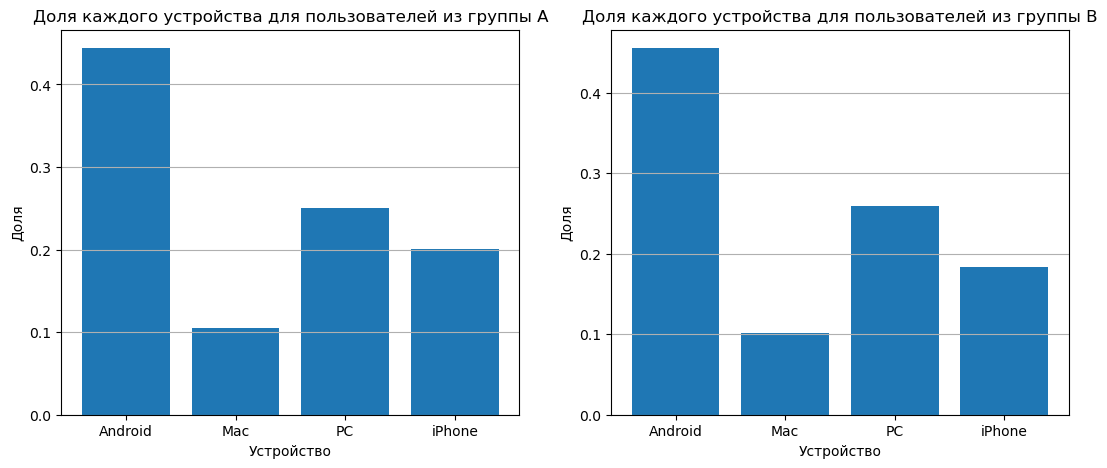

In [60]:
# строим график, отражающий долю каждого типа устройств в группах А и В
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# группа А
ax1.bar(percent_a.index, percent_a.values)
ax1.set_title('Доля каждого устройства для пользователей из группы А')
ax1.set_xlabel('Устройство')
ax1.set_ylabel('Доля')
ax1.grid(axis = 'y')

# группа В
ax2.bar(percent_b.index, percent_b.values)
ax2.set_title('Доля каждого устройства для пользователей из группы B')
ax2.set_xlabel('Устройство')
ax2.set_ylabel('Доля')
ax2.grid(axis = 'y')

# показываем график
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

In [61]:
# считаем долю пользователей в каждом регионе в группах А и В
region_a = a.groupby('region')['user_id'].nunique()/a.groupby('region')['user_id'].nunique().sum()
region_b = b.groupby('region')['user_id'].nunique()/b.groupby('region')['user_id'].nunique().sum()
print(f'Доля пользователей по регионам в группе А \n{region_a} \n\nДоля пользователей по регионам в группе В\n{region_b}')

Доля пользователей по регионам в группе А 
region
CIS     0.436019
EU      0.151659
MENA    0.412322
Name: user_id, dtype: float64 

Доля пользователей по регионам в группе В
region
CIS     0.439973
EU      0.148022
MENA    0.412005
Name: user_id, dtype: float64


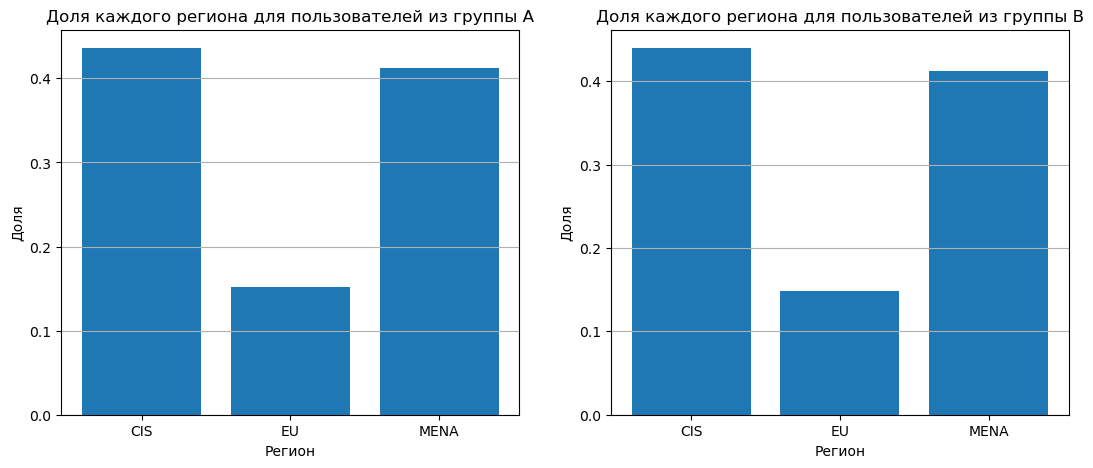

In [62]:
# строим график, отражающий долю пользователей в каждом регионе в группах А и В
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# группа А
ax1.bar(region_a.index, region_a.values)
ax1.set_title('Доля каждого региона для пользователей из группы А')
ax1.set_xlabel('Регион')
ax1.set_ylabel('Доля')
ax1.grid(axis = 'y')

# группа В
ax2.bar(region_b.index, region_b.values)
ax2.set_title('Доля каждого региона для пользователей из группы B')
ax2.set_xlabel('Регион')
ax2.set_ylabel('Доля')
ax2.grid(axis = 'y')

# показываем график
plt.show()

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

- В обеих выборках находится практически равное количество пользователей, 1477 и 1466 соответственно (различие совсем незначительное - 0,74%).
- Выборки являются независимыми - в данных нет пользователей, относящимся к двум группам одновременно.
- Доли пользователей по устройствам и по регионам также практически равны - сохраняется равномерное распределение пользователей тестовой и контрольной групп.

A/B-тест проходит корректно.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [63]:
# сохраняем датафрейм с данными о всем периоде A/B тестирования
sessions_test = pd.read_csv('sessions_project_test.csv')

# создаем новый столбец, значение 1 - если за сессию просмотрено 4 и больше страниц, 0 - если меньше
sessions_test['good_session'] = 1
sessions_test.loc[sessions_test['page_counter'] < 4, 'good_session'] = 0

# проверяем результат
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

Целевой метрикой в эксперименте будет `доля успешных первых сессий` пользователей. 
- Нулевая гипотеза: доли успешных первых сессий пользователей равны в группах А и В.
- Альтернативная гипотеза: доля успешных первых сессий пользователей в группе В выше, чем в группе А.
 
В качестве `прокси метрик` можно было бы выбрать DAU(количество активных пользователей в день), долю пользователей с подпиской и среднее время, проведенное пользователем в приложении. В качестве `барьерных метрик` я бы взяла среднее время загрузки страницы (оно не должно сильно снижаться), среднее количество дизлайков/'не интересно' на видео, среднее количество обращений в поддержку.

#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [64]:
# делим на группы А и В и оставляем данные только о первых сессиях
a = sessions_test[(sessions_test['test_group'] == 'A')&(sessions_test['session_number'] == 1)]
b = sessions_test[(sessions_test['test_group'] == 'B')&(sessions_test['session_number'] == 1)]

# считаем долю успешных первых сессий в каждой группе
good_a = a['good_session'].mean()
good_b = b['good_session'].mean()

print(f'Доля успешных первых сессий в группе А равна {round(good_a*100, 2)}%, в группе В: {round(good_b*100,2)}%. Разница составляет {round((good_b-good_a)*100, 2)}%.')

Доля успешных первых сессий в группе А равна 31.57%, в группе В: 31.47%. Разница составляет -0.11%.


In [65]:
# рассчитаем длительность эксперимента
print(f"Длительность эксперимента {pd.to_datetime(sessions_test['session_date']).max() - pd.to_datetime(sessions_test['session_date']).min()}.")

Длительность эксперимента 19 days 00:00:00.


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

Проверим гипотезы:
- Нулевая: доли успешных первых сессий пользователей равны в группах А и В.
- Альтернативная: доля успешных первых сессий пользователей в группе В больше, чем в группе А.

Будем использовать z-тест пропорций.

In [66]:
# считаем размеры выборок
n_a = a.shape[0]
n_b = b.shape[0]
print(f'В группе А {n_a} пользователей, в группе В {n_b} пользователей. Всего в группах {n_a+n_b} пользователей.')

# считаем кол-во успехов в выборках
m_a = a['good_session'].sum()
m_b = b['good_session'].sum()

# устанавливаем уровень значимости 5%
alpha = 0.05

p_a, p_b = m_a/n_a, m_b/n_b

# проверяем, выполняется ли предпосылка о достаточном количестве данных
if (p_a*n_a>10) and ((1-p_a)*n_a > 10) and (p_b*n_b>10) and ((1-p_b)*n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется.')
else:
    print('Предпосылка о достаточном количестве данных не выполняется.')

stat_ztest, p_value = proportions_ztest(
    [m_b, m_a],
    [n_b, n_a],
    alternative = 'larger'
)

print(f'p-value: {p_value}')

# сравниваем p-value и уровень значимости
if p_value < alpha:
    print('Нулевая гипотеза не находит подтверждения.')
else:
    print('Не получилось отвергнуть нулевую гипотезу.')

В группе А 15162 пользователей, в группе В 15416 пользователей. Всего в группах 30578 пользователей.
Предпосылка о достаточном количестве данных выполняется.
p-value: 0.5783523649187868
Не получилось отвергнуть нулевую гипотезу.


#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

По результатам А/В тестирования можно подвести следующие итоги:
- Мы провели эксперимент, в котором у пользователей контрольной группы А была старая версия приложения, а у пользователей группы В в приложении был новый алгоритм рекомендаций. Пользователи каждой группы были равномерно распределены по регионам и типам устройств. Всего в эксперименте участвовало 30578 пользователей, длительность эксперимента - 19 дней.
- Внедрение нового алгоритма рекомендаций не повлияло положительно на целевую метрику - долю успешных первых сессий пользователей. Тест показал, что в тестовой группе метрика не увеличилась.
- Значение p-value для оценки статистической значимости выявленного эффекта получилось 0.5783523649187868.
- Нецелесообразно тратить ресурсы на внедрение нововведения в приложение, так как не наблюдалось никакого положительного эффекта.